<a href="https://colab.research.google.com/github/Nusrat-96/Bengali_data_analysi/blob/main/Urban_Rural_Population_Growth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [2]:
!pip install wbgapi

In [3]:
import wbgapi as wb

# Show Available Database in the WB

In [4]:
print(wb.source.info())  # Should show available databases

id    name                                                                  code      concepts  lastupdated
----  --------------------------------------------------------------------  ------  ----------  -------------
1     Doing Business                                                        DBS              3  2021-08-18
2     World Development Indicators                                          WDI              3  2025-07-01
3     Worldwide Governance Indicators                                       WGI              3  2024-11-05
5     Subnational Malnutrition Database                                     SNM              3  2016-03-21
6     International Debt Statistics                                         IDS              4  2025-02-26
11    Africa Development Indicators                                         ADI              3  2013-02-22
12    Education Statistics                                                  EDS              3  2024-06-25
13    Enterprise Surveys         

# Lets explore "World Development Indicators" Dataset

## To access Specific Data we need a indicators

In [5]:
# Search for GDP-related indicators
wb.db = 2
population_indicators = wb.series.info(q='population growth')
print(population_indicators)

id              value
--------------  ----------------------------------
SP.POP.GROW     Population growth (annual %)
SP.RUR.TOTL.ZG  Rural population growth (annual %)
SP.URB.GROW     Urban population growth (annual %)
                3 elements


## Access Data

### Population Growth of last 24 years  (2000 to 2024)

### Population growth (annual %)

In [19]:
p_growth = wb.data.DataFrame('SP.URB.GROW',
                            economy=['BGD'],
                            time=range(2000, 2025))

p_growth.columns = [col.replace("YR", "") for col in p_growth.columns]    # in the ori


p_growth.head()

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
economy,,,,,,,,,,,,,,,,,,,,,
BGD,3.485769,3.78919,4.245608,4.137545,4.019679,3.887273,3.767803,3.658558,3.554302,3.457718,...,3.172709,3.126244,3.035919,2.956502,2.934632,2.879197,2.80926,2.969449,3.122401,3.067728


### Rural and Urban population growth (annual %)

```
id              value
--------------  ----------------------------------
SP.POP.GROW     Population growth (annual %)
SP.RUR.TOTL.ZG  Rural population growth (annual %)
SP.URB.GROW     Urban population growth (annual %)
                3 elements

```

In [25]:
indicators = ["SP.POP.GROW", "SP.RUR.TOTL.ZG", "SP.URB.GROW"]

# Fetch data for Bangladesh (2020–2023)
years = range(2000, 2025)
bgd_p_growth = wb.data.DataFrame(indicators, economy="BGD", time=years).reset_index()

# Dynamically rename columns: 'series' + years
bgd_p_growth.columns = ["Indicator"] + [str(year) for year in years]

print(bgd_p_growth.head())


        Indicator      2000      2001      2002      2003      2004      2005  \
0     SP.POP.GROW  1.827328  1.666893  1.543406  1.455305  1.361548  1.260665   
1  SP.RUR.TOTL.ZG  1.320826  1.002474  0.670085  0.556857  0.438715  0.315575   
2     SP.URB.GROW  3.485769  3.789190  4.245608  4.137545  4.019679  3.887273   

       2006      2007      2008  ...      2015      2016      2017      2018  \
0  1.161168  1.075643  0.998441  ...  0.893819  0.892432  0.850917  0.820955   
1  0.189126  0.077340 -0.025414  ... -0.276015 -0.294330 -0.350099 -0.393082   
2  3.767803  3.658558  3.554302  ...  3.172709  3.126244  3.035919  2.956502   

       2019      2020      2021      2022      2023      2024  
0  0.846411  0.836311  0.814978  1.024234  1.221715  1.214621  
1 -0.380949 -0.404684 -0.436696 -0.236671 -0.050253 -0.065226  
2  2.934632  2.879197  2.809260  2.969449  3.122401  3.067728  

[3 rows x 26 columns]


## Visualize Data

In [26]:
# Set indicator as index for plotting
bgd_p_growth.set_index("Indicator", inplace=True)    # have to run one time, second time run will show error



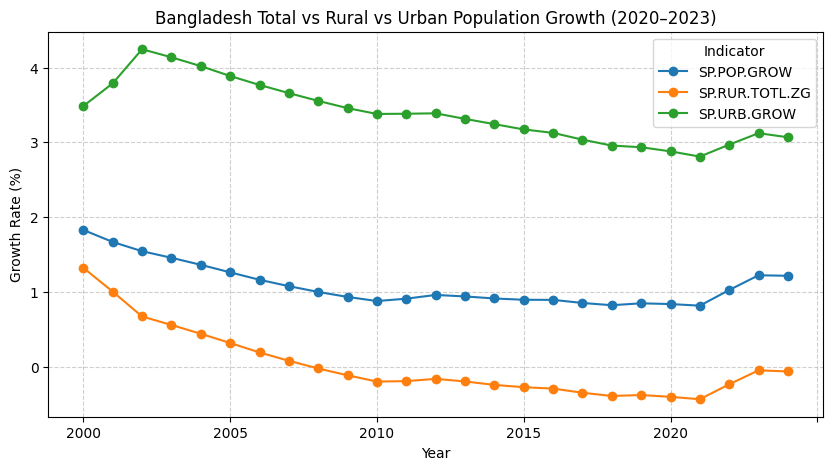

In [27]:
import matplotlib.pyplot as plt

# Transpose so years are x-axis
bgd_p_growth.T.plot(figsize=(10,5), marker='o')

plt.title("Bangladesh Total vs Rural vs Urban Population Growth (2020–2023)")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Indicator")
plt.show()
